# Grid Search: Ottimizzazione Parametri HDBSCAN
Questo notebook esegue una grid search iterativa per trovare i migliori parametri di clustering per il nostro dataset di email.

**Ottimizzazione Computazionale**: Per evitare tempi di calcolo biblici (ricordiamo che HDBSCAN puro richiedeva 10+ minuti a run), la riduzione UMAP a 15D viene calcolata **una sola volta** all'inizio e tenuta in cache nella RAM.
Successivamente, un ciclo `for` lancia HDBSCAN (che su 15D impiega pochi secondi) testando decine di combinazioni di `min_cluster_size` e `min_samples`.

In [1]:
import numpy as np
import pandas as pd
import json
import os
import sys
import umap
import hdbscan
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time

sys.path.append(os.path.abspath(os.path.join('..', '..')))

# Path dai DATA_CONTRACTS
EMBEDDINGS_PATH = "../../data/embeddings/email_embeddings_bge-small-en-v1-5.npy"
print("Caricamento embeddings...")
embeddings = np.load(EMBEDDINGS_PATH)
print(f"Shape: {embeddings.shape}")

Caricamento embeddings...
Shape: (42471, 384)


In [2]:
# FASE 1: UMAP Caching
# Riduciamo la dimensionalità una volta sola per tutto il grid search per preservare il tempo di calcolo.
UMAP_DIMENSIONS = 15

print(f"Calcolo UMAP ({UMAP_DIMENSIONS}D)...")
start_time = time.time()
reducer = umap.UMAP(n_neighbors=15, n_components=UMAP_DIMENSIONS, metric='cosine', random_state=42)
embeddings_ridotti = reducer.fit_transform(embeddings)
print(f"UMAP completato in {time.time() - start_time:.2f} secondi.")


Calcolo UMAP (15D)...


/home/filippo/Scrivania/pizza-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP completato in 40.80 secondi.


In [3]:
# FASE 2: Grid Search HDBSCAN
# Definiamo i range da esplorare
min_cluster_sizes = [30, 50, 100, 150, 200]
min_samples_list = [5, 10, 15, 30, 50]

results = []

print("Avvio Grid Search...")
for mcs in tqdm(min_cluster_sizes, desc="min_cluster_size"):
    for ms in min_samples_list:
        # Per convenzione, min_samples non dovrebbe superare min_cluster_size
        if ms > mcs:
            continue 
            
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms,
            metric='euclidean',
            cluster_selection_method='eom',
            prediction_data=False, # Disabilitato per velocizzare il grid search
            core_dist_n_jobs=8
        )
        
        clusterer.fit(embeddings_ridotti)
        
        labels = clusterer.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_pct = (n_noise / len(labels)) * 100
        
        # Estraiamo la Relative Validity (DBCV) calcolata internamente da HDBSCAN.
        # È una metrica che premia cluster densi e ben separati. 
        validity = getattr(clusterer, 'relative_validity_', None)
        
        results.append({
            'min_cluster_size': mcs,
            'min_samples': ms,
            'n_clusters': n_clusters,
            'noise_points': n_noise,
            'noise_pct': noise_pct,
            'relative_validity': validity
        })

df_results = pd.DataFrame(results)
# Ordiniamo prima per validità decrescente, poi per percentuale di rumore crescente
df_results.sort_values(by=['noise_pct', 'n_clusters'], ascending=[True, False], inplace=True)


Avvio Grid Search...


min_cluster_size:   0%|          | 0/5 [00:00<?, ?it/s]

In [4]:
# Visualizziamo i migliori risultati
display(df_results.head(15))

# Salviamo i risultati del grid search
os.makedirs("../../data/metadata", exist_ok=True)
df_results.to_csv("../../data/metadata/hdbscan_gridsearch_results.csv", index=False)
print("Risultati salvati in data/metadata/hdbscan_gridsearch_results.csv")


,min_cluster_size,min_samples,n_clusters,noise_points,noise_pct,relative_validity
19,200,5,32,13213,31.110640,None
0,30,5,364,13914,32.761178,None
1,30,10,337,14922,35.134562,None
2,30,15,335,15466,36.415436,None
4,50,5,212,16684,39.283276,None
10,100,10,88,17060,40.168586,None
5,50,10,201,17192,40.479386,None
6,50,15,190,17259,40.637141,None
20,200,10,40,17461,41.112759,None
3,30,30,280,17671,41.607214,None


Risultati salvati in data/metadata/hdbscan_gridsearch_results.csv


Generazione dei plot per i 9 migliori risultati. Ricalcolo rapido in corso...


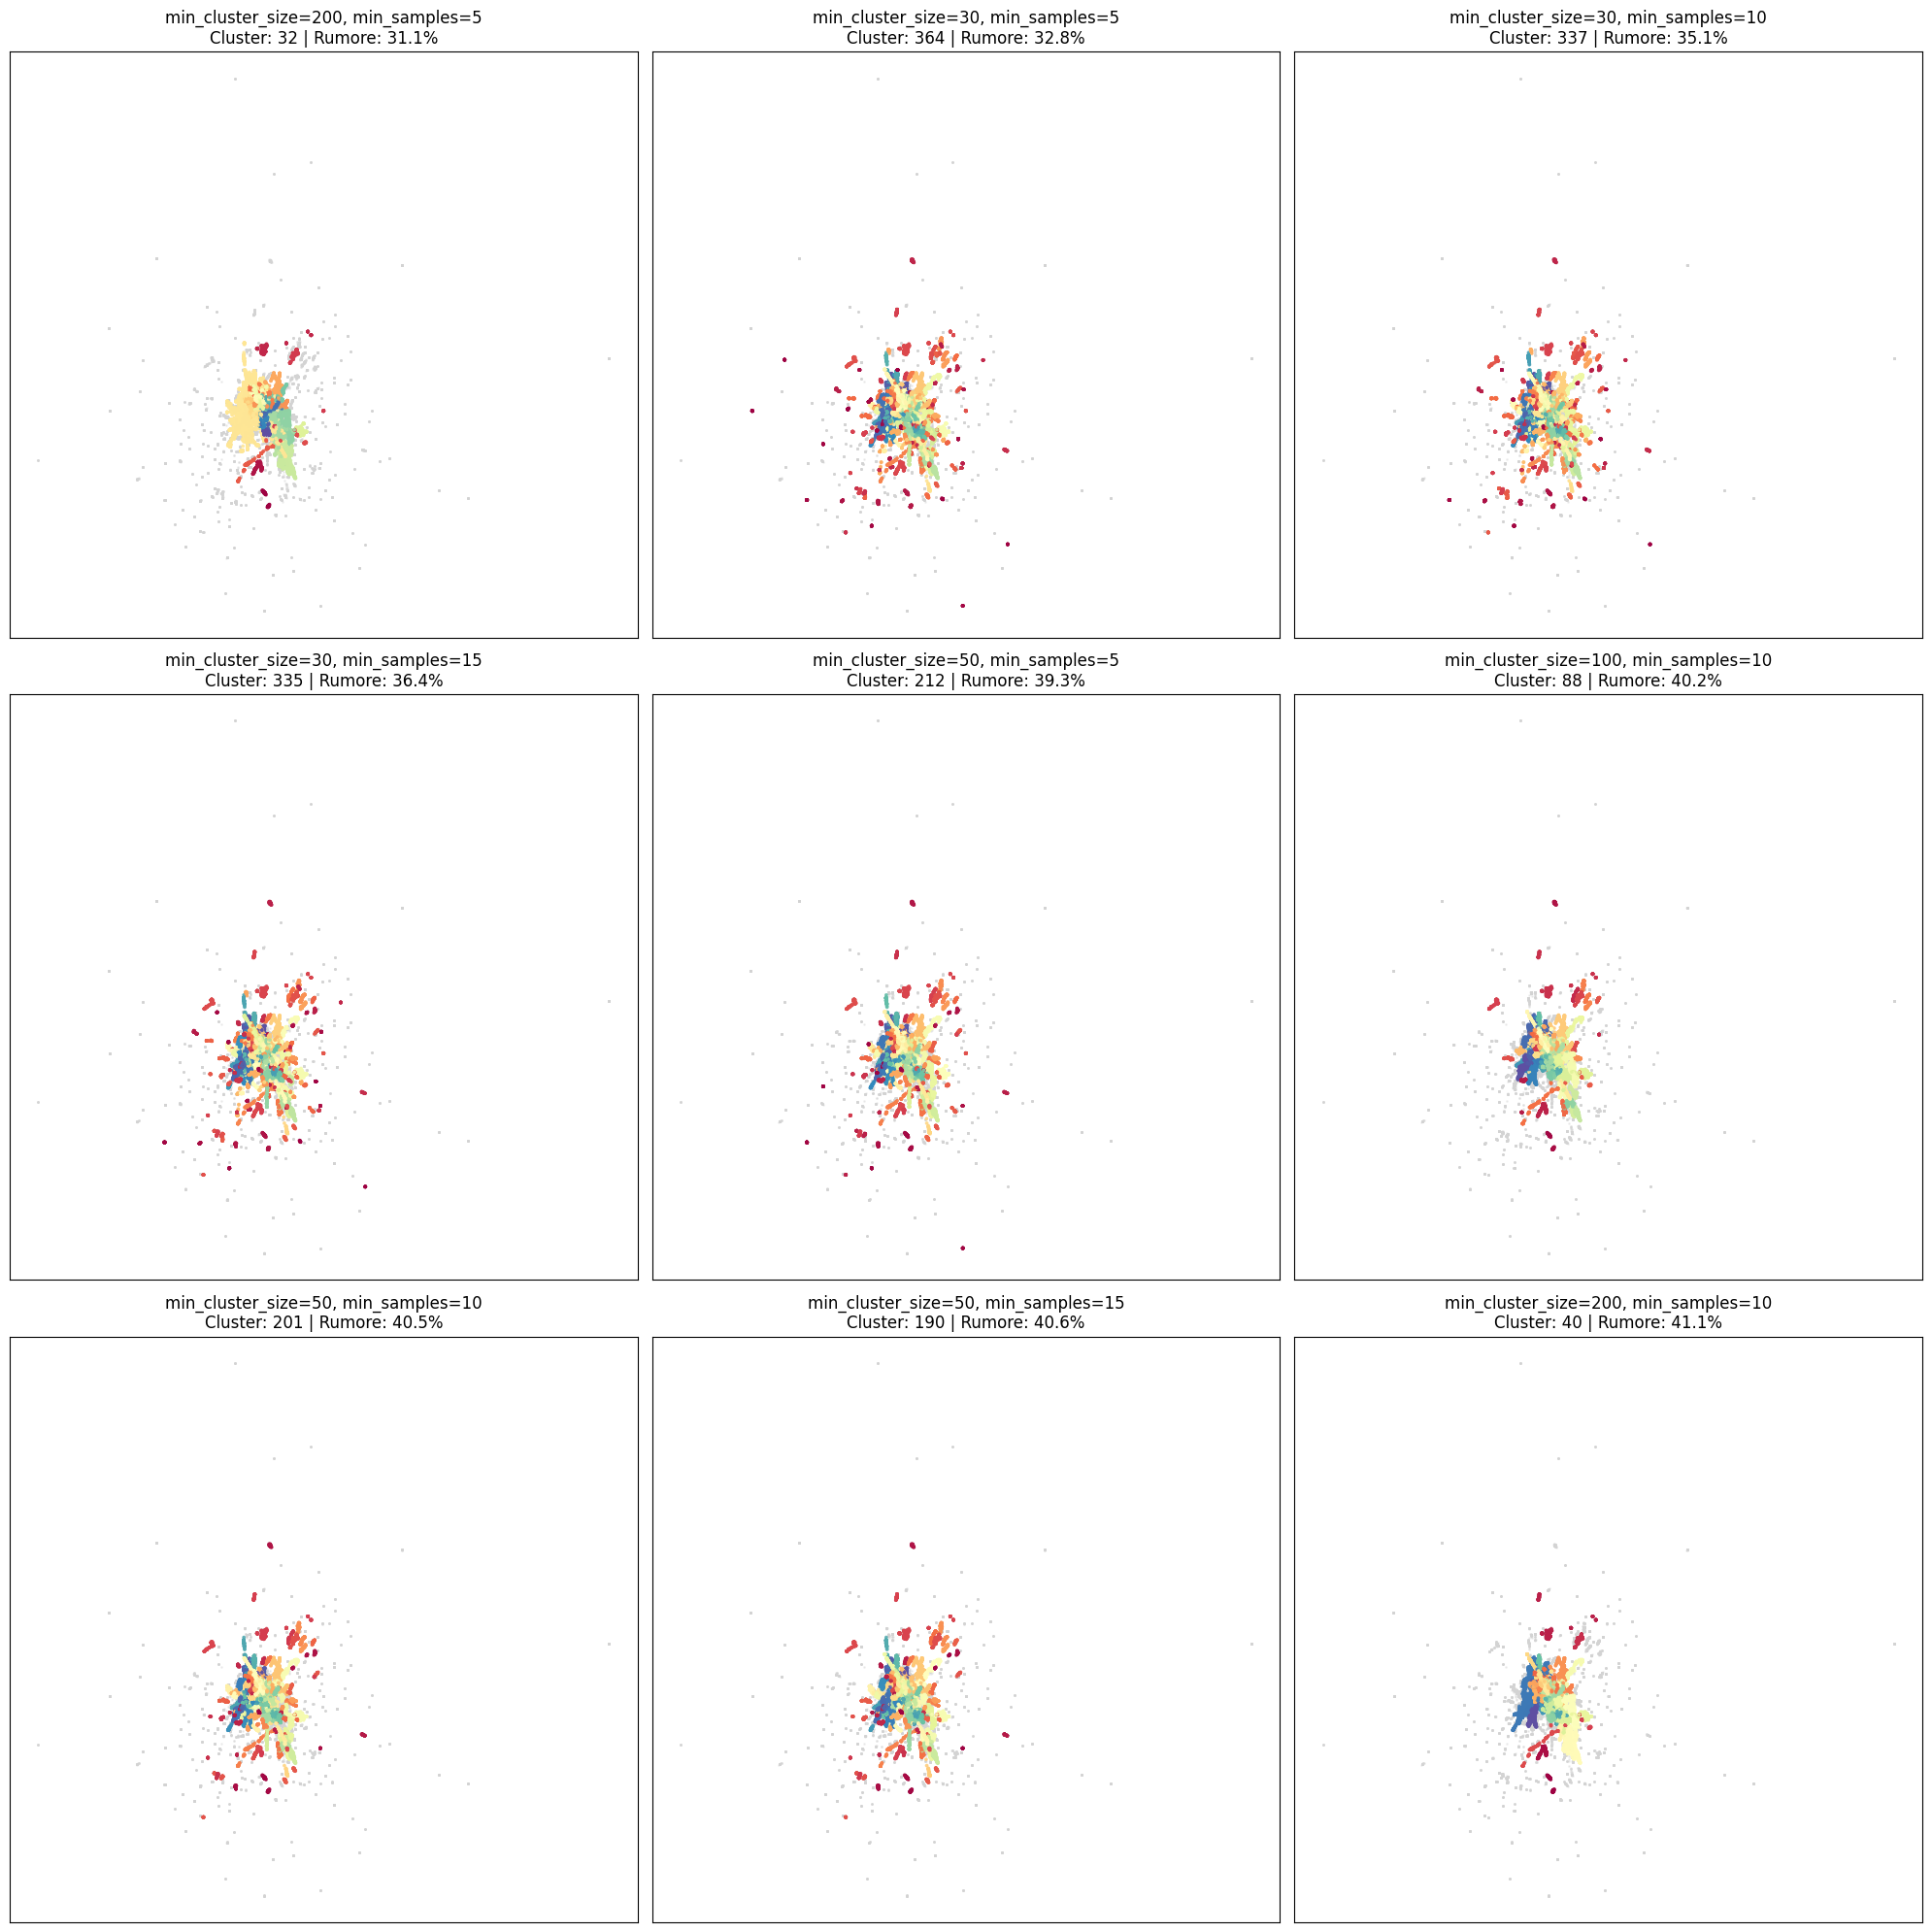

In [5]:
# FASE 3: Visualizzazione dei 9 migliori risultati
# Creiamo una griglia 3x3 per confrontare visivamente come i diversi parametri frammentano lo spazio.

top_9 = df_results.head(9)

fig, axes = plt.subplots(3, 3, figsize=(20, 20))
axes = axes.flatten()

print("Generazione dei plot per i 9 migliori risultati. Ricalcolo rapido in corso...")

for i, (idx, row) in enumerate(top_9.iterrows()):
    mcs = int(row['min_cluster_size'])
    ms = int(row['min_samples'])
    
    # Ricalcoliamo rapidamente i cluster per questa specifica configurazione
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms,
        metric='euclidean',
        cluster_selection_method='eom',
        core_dist_n_jobs=8
    )
    labels = clusterer.fit_predict(embeddings_ridotti)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = row['noise_pct']
    
    ax = axes[i]
    
    # Disegniamo prima il rumore in grigio chiaro
    noise_mask = (labels == -1)
    ax.scatter(embeddings_ridotti[noise_mask, 0], embeddings_ridotti[noise_mask, 1], 
               c='lightgray', s=1, alpha=0.3)
               
    # Disegniamo i cluster colorati
    cluster_mask = (labels != -1)
    ax.scatter(embeddings_ridotti[cluster_mask, 0], embeddings_ridotti[cluster_mask, 1], 
               c=labels[cluster_mask], cmap='Spectral', s=3, alpha=0.8)
               
    ax.set_title(f"min_cluster_size={mcs}, min_samples={ms}\nCluster: {n_clusters} | Rumore: {noise_pct:.1f}%", fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

Generazione dei plot gerarchici per i 9 migliori risultati. Ricalcolo in corso...


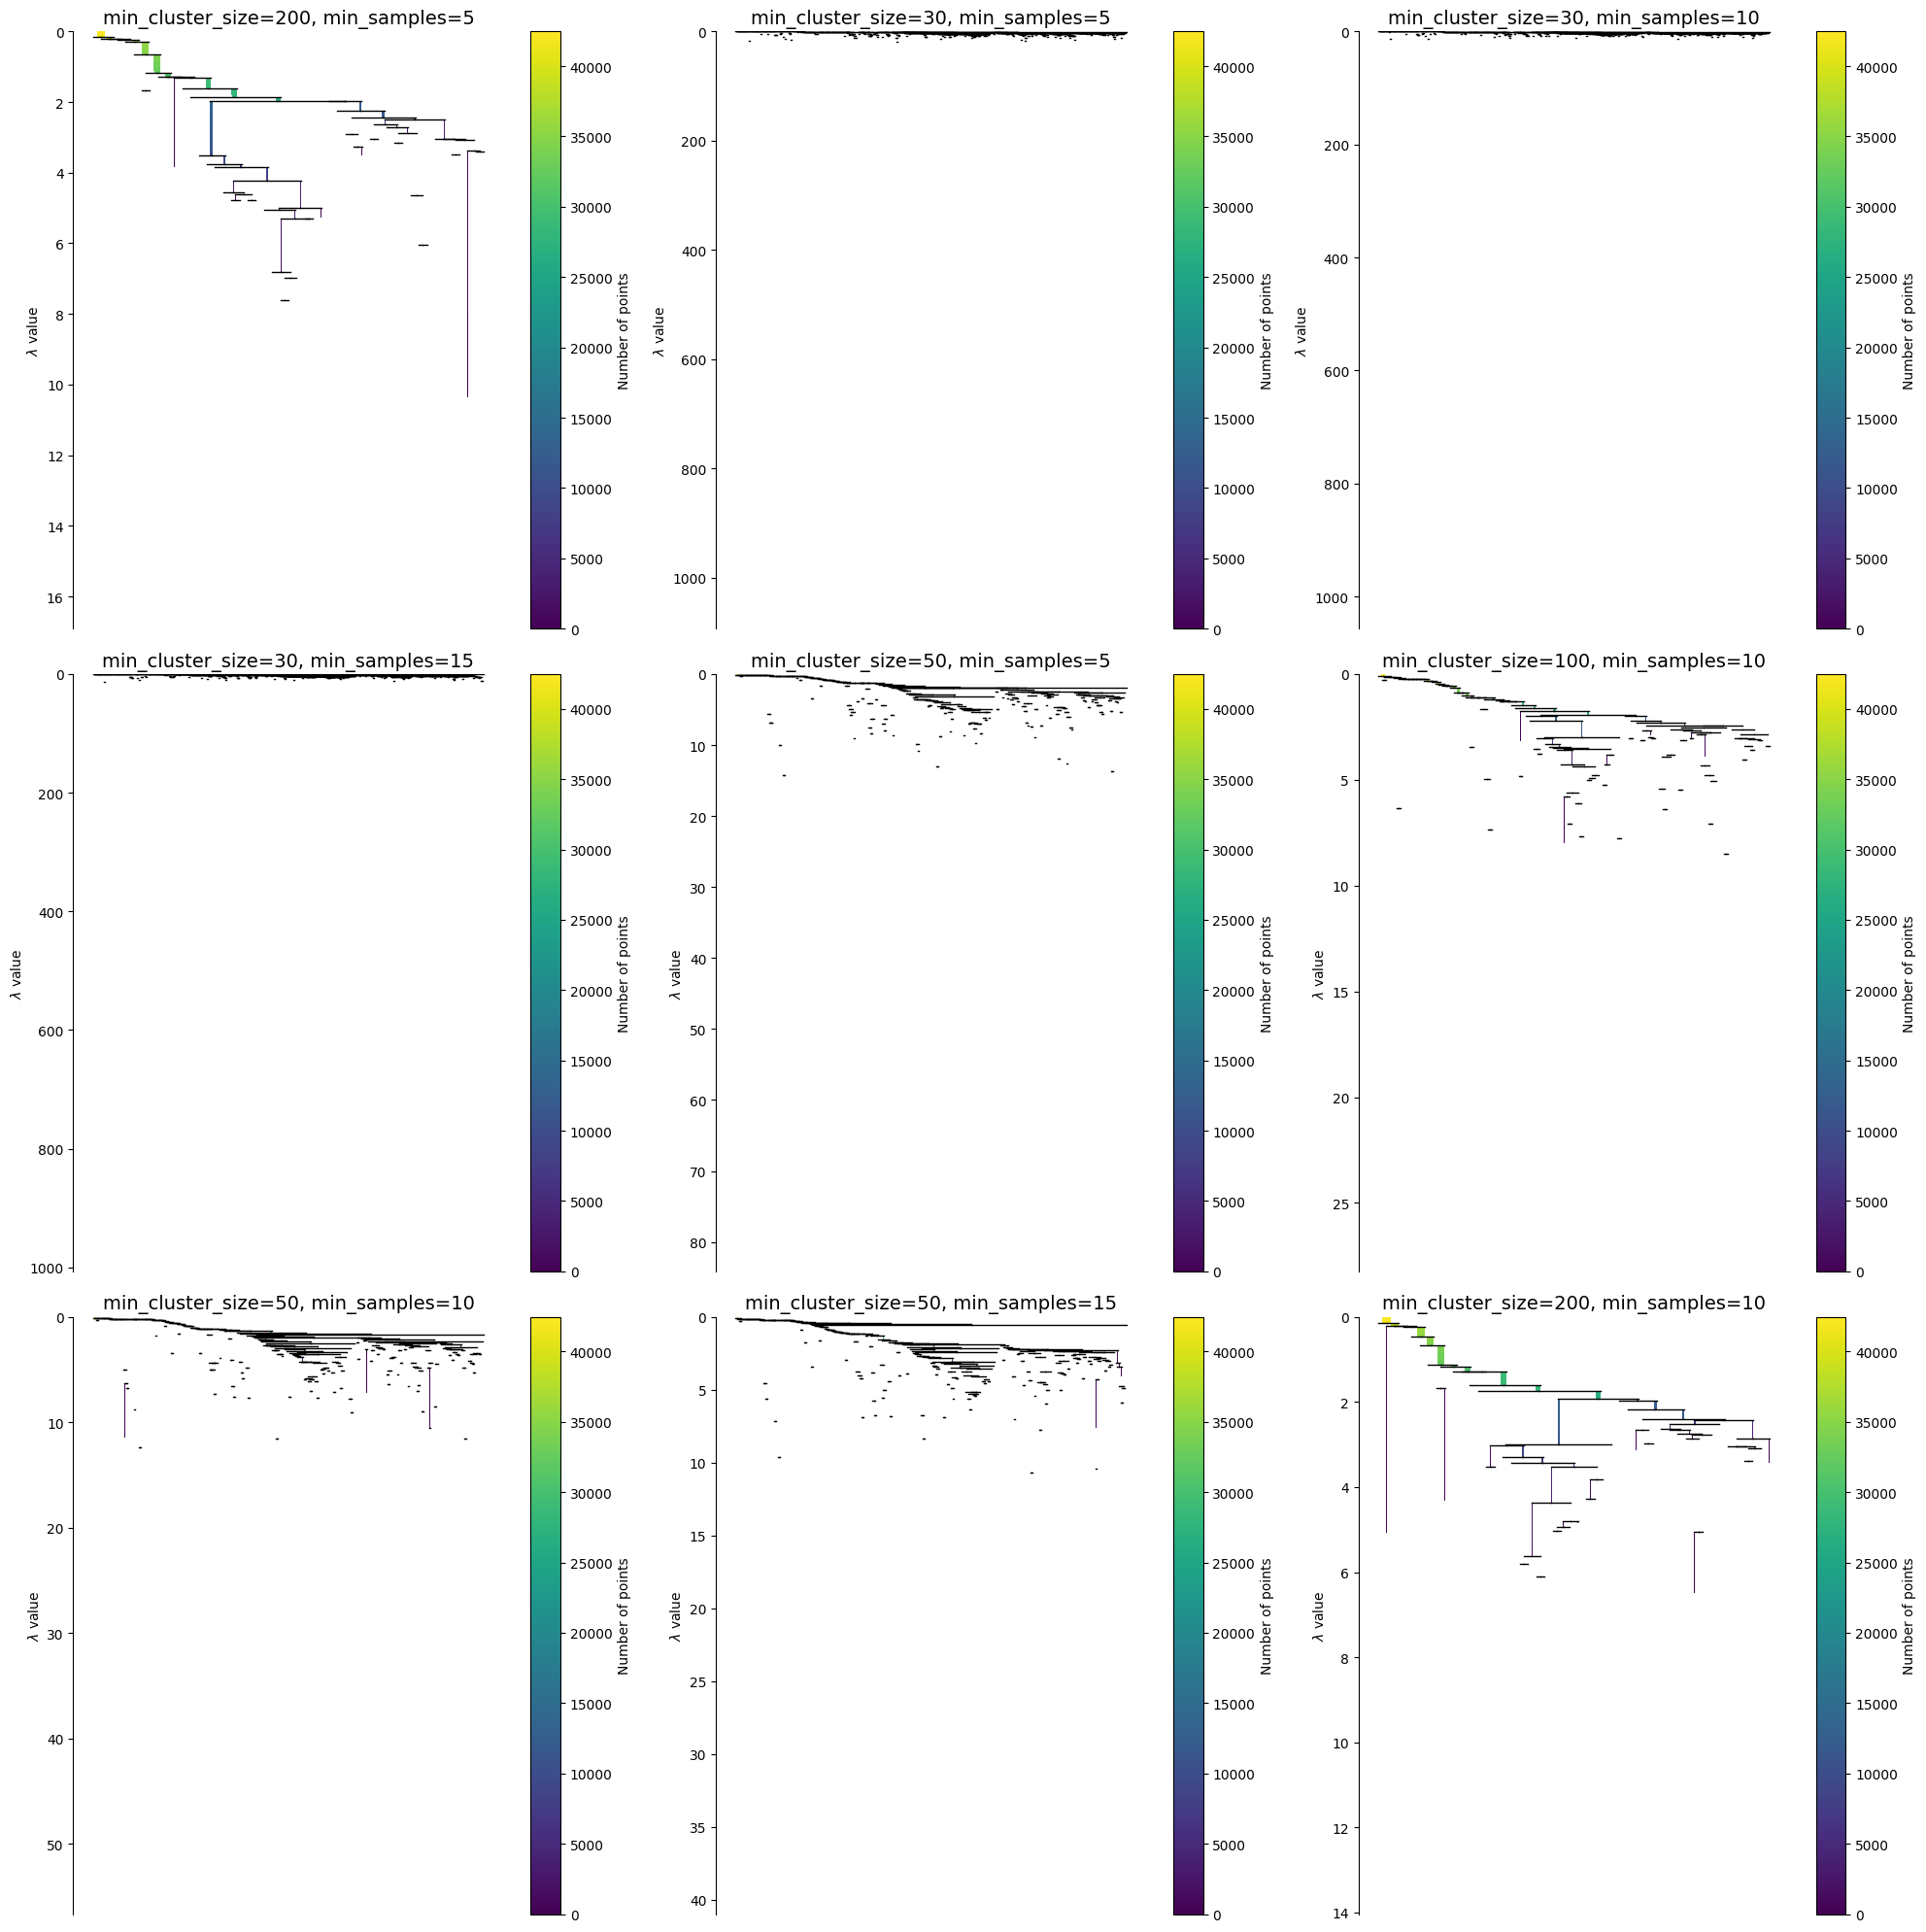

In [6]:
# FASE 4: Albero Gerarchico delle Densità per i 9 migliori risultati
# Confrontiamo come cambiano i rami e i tagli dei cluster al variare dei parametri.

fig, axes = plt.subplots(3, 3, figsize=(20, 20))
axes = axes.flatten()

print("Generazione dei plot gerarchici per i 9 migliori risultati. Ricalcolo in corso...")

for i, (idx, row) in enumerate(top_9.iterrows()):
    mcs = int(row['min_cluster_size'])
    ms = int(row['min_samples'])
    
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms,
        metric='euclidean',
        cluster_selection_method='eom',
        core_dist_n_jobs=8
    )
    clusterer.fit(embeddings_ridotti)
    
    ax = axes[i]
    
    # Impostiamo l'asse corrente in modo che HDBSCAN disegni nel riquadro giusto della griglia
    plt.sca(ax)
    
    # Disegniamo l'albero condensato (usiamo select_clusters=False di default omettendo il parametro per evitare bug)
    clusterer.condensed_tree_.plot()
               
    ax.set_title(f"min_cluster_size={mcs}, min_samples={ms}", fontsize=14)
    ax.set_xticks([])

plt.tight_layout()
plt.show()